## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable.

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes.

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values.

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health?

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

Training MSE: 1.3817905374330289e-30


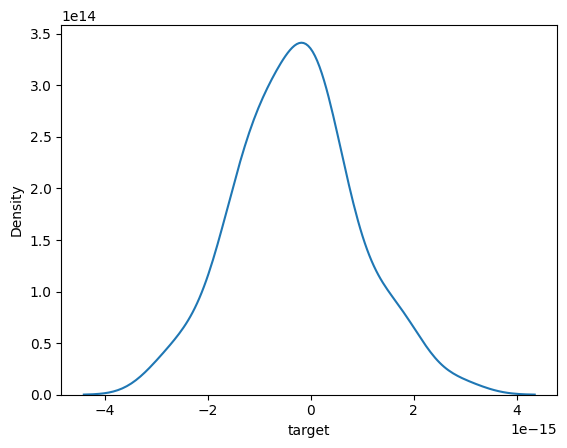

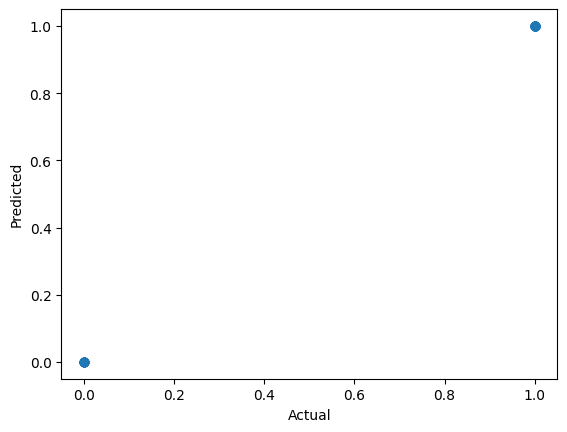

In [11]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/golub.csv', encoding='utf-8')

# Part 1
df["target"] = df["cancer"].map({
    "allB": 1,
    "allT": 1,
    "aml": 0
})

X = df.drop(columns=["cancer", "target"])
X = X.select_dtypes(include=["number"])
y = df["target"]

# Part 2, linear regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

mse = mean_squared_error(y, y_pred)
print("Training MSE:", mse)

import matplotlib.pyplot as plt
import seaborn as sns

residuals = y - y_pred

# KDE plot
sns.kdeplot(residuals)
plt.show()

# Scatter plot
plt.scatter(y, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()


Q2 Response: The linear regression outputted an MSE of 1.3817905374330289e-30, which is nearly 0, because the number of features greatly exceeds the number of observations, allowing the model to perfectly estimate the data. This indicates the model overfitted a lot by memorizing, not learning

In [12]:
# Part 3, cross validation
from sklearn.model_selection import cross_val_score
import numpy as np

cv_mse = -cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=5,
    scoring="neg_mean_squared_error"
)

print("CV MSE:", np.mean(cv_mse))

CV MSE: 0.06012310356203804


The linear regression model had an almost zero training error, which means it has very low bias and can fit the training data extremely well.

However, the cross-validation MSE is higher (0.06), showing that the model doesn’t generalize perfectly to new data. This indicates high variance. Since there are many more features than samples, the model is likely overfitting by memorizing the training data instead of learning real patterns. So overall, this is a low bias, high variance model, which explains why regularization methods like LASSO are needed.

105.24436668425457
Selected genes: Index(['HG3549-HT3751_at', 'J04164_at', 'L38941_at', 'M11147_at', 'M11722_at',
       'M17733_at', 'M19507_at', 'M26602_at', 'M27891_at', 'M33680_at',
       'M63138_at', 'M77232_rna1_at', 'M91036_rna1_at', 'M96326_rna1_at',
       'U14968_at', 'X04500_at', 'X17042_at', 'X78992_at', 'Z70759_at',
       'L06797_s_at', 'D49824_s_at', 'M25079_s_at', 'X57351_s_at',
       'V00594_s_at', 'U05255_s_at', 'X03689_s_at', 'M14328_s_at',
       'M14483_rna1_s_at', 'M26708_s_at', 'Y00787_s_at', 'Z19554_s_at',
       'X56681_s_at', 'HG2887-HT3031_at', 'M33600_f_at'],
      dtype='object')
Num selected: 34
Num discarded: 7096


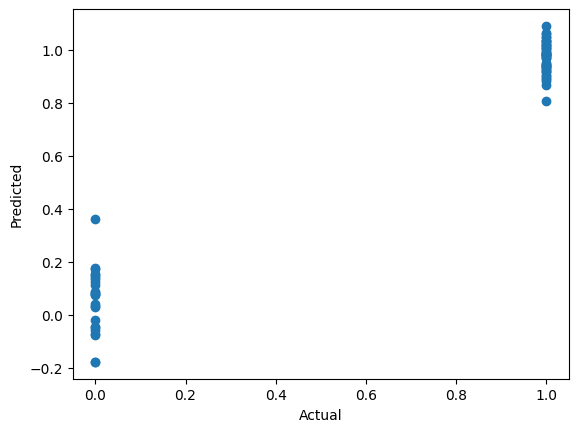

In [15]:
# Part 4, LASSO
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=5, max_iter=10000)
lasso.fit(X, y)

y_pred_lasso = lasso.predict(X)

print(lasso.alpha_)

# Selected genes
import numpy as np

coef = lasso.coef_

selected_genes = X.columns[coef != 0]
discarded_genes = X.columns[coef == 0]

print("Selected genes:", selected_genes)
print("Num selected:", len(selected_genes))
print("Num discarded:", len(discarded_genes))

# Scatterplot
plt.scatter(y, y_pred_lasso)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

For part 4, the model selected 34 genes and discarded 7086. The scatter plot also has an increased spread which indicates that the LASSO model no longer perfectly fits the training data. It now produces more moderate predictions, reflecting the effect of regularization. This reduces overfitting and leads to better generalization.

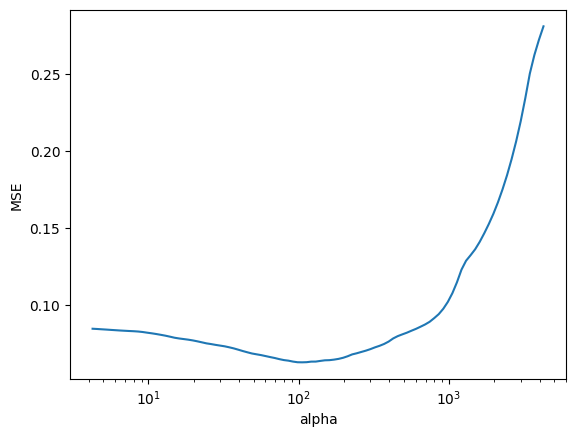

In [16]:
# Part 5
mse_path = lasso.mse_path_.mean(axis=1)
alphas = lasso.alphas_

plt.plot(alphas, mse_path)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("MSE")
plt.show()

Alphda is overfitting for smaller values of alpha. Then, at about alpha=100, the MSE is the lowest, indicating the best bias-variance tradeoff. Then, as alpha increases, the MSE increases dramatically, indicating underfitting because it is high bias.

**Question 6: Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.**

LASSO works better because instead of trying to use all of the genes, it shrinks a lot of those coefficients down to zero and keeps only the ones that are significant. If it used all the genes, it would lead to memorization. Therefore, the model ends up being simpler and less sensitive to random fluctuations in the data. That makes it better at generalizing to new patients instead of just fitting the training set perfectly.

**Question 7: Why do regularization methods lend themselves to scenarios like precision health?**
Regularization methods are useful for precision health beacause you're often times using more features than samples, such as having thousands of genes but only a few dozen patients. Most of those genes are not significant for the specific disease you’re studying. Regularization helps to focus on the small subset of genes that are actually predictive. This makes it useful in precision health, because those selected genes can point to potential biomarkers or targets for treatment.

**Question 8: What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?**

One risk is that LASSO might throw away genes that are actually biologically important, just because they don’t look strong in this particular dataset. Also, with such a small sample size, the results might be unstable because if you changed the data slightly, you might get a totally different set of selected genes. That is a risk in a healthcare setting, because you don’t want to base medical decisions on something that might not hold up. It can give a false sense of confidence in the model which might not generalize well in real life.